In [ ]:
# インストール済みの場合は実行不要
!pip install "quri-parts[qulacs]"

この補足ノートでは、書籍の4.3節「その他の量子ダイナミクスシミュレーション」の最後のページ（P132）で紹介した量子信号処理(quantum signal processing, QSP)による量子ダイナミクスシミュレーション（参考文献[1]）の実装例を紹介する。このノートの記法は以下の参考文献[2]に基づいている。

- 参考文献[1]: Guang Hao Low and Isaac L. Chuang, "Hamiltonian Simulation by Qubitization", Quantum 3, 163 (2019) https://doi.org/10.22331/q-2019-07-12-163
- 参考文献[2]: John M. Martyn _et al._, "Grand Unification of Quantum Algorithms", PRX Quantum 2, 040203 (2021) https://doi.org/10.1103/PRXQuantum.2.040203


# 1. 量子信号処理(QSP)
## 1.1 $W_x$記法による定義
QSPはもともとNMR（核磁気共鳴）などで用いられてきたパルス信号処理の技術をもとに発展した技術である。
QSPでは、まず次のような2つの1量子ビットゲートを定義する（後述するが、ここでは$W_x$記法というものを用いている）。
$$
\begin{eqnarray}
W_x(a) &=& \begin{pmatrix} a & i \sqrt{1 - a^2} \\ i \sqrt{1 - a^2} & a \end{pmatrix}
  = \exp \left( i \arccos(a) X \right), \\
S_z(\phi) &=& \begin{pmatrix} e^{i \phi} & 0 \\ 0 & e^{-i \phi} \end{pmatrix} = \exp \left( i \phi Z \right)
\end{eqnarray}
$$
ここで$a$は$-1 \leq a \leq 1$を満たす実数で、$\phi$も実数であるとする。
この2つのゲートを交互に$d$回繰り返した、以下のような$2\times 2$ユニタリ行列を考える。
$$
U_{\mathrm{QSP},W_x}(\phi_0, ..., \phi_d) = S_z(\phi_0) W_x(a) S_z(\phi_1) W_x(a) ... W_x(a) S_z(\phi_d)
 = \begin{pmatrix} P'(a) & i \sqrt{1 - a^2} Q'(a) \\ i \sqrt{1 - a^2} {Q'}^*(a) & {P'}^*(a) \end{pmatrix} \tag{1}
$$
このように定義すると、$P'(a), Q'(a)$は$a$の(複素数係数の)$d$次の多項式となる。
QSPの目標は、角度$\phi_0, ..., \phi_d$を適切に選ぶことで、$a$の多項式$P'(a)$をなんらかのターゲット関数$f_\mathrm{target}(a)$に近づけることである。

多項式$P'(a),Q'(a)$が具体的にどのような形をしているのか、SymPyを用いてシンボリックに計算してみよう。

In [2]:
import math
import numpy as np
import sympy as sp
sp.init_printing() # sympyの数式をきれいに表示するための設定

a = sp.symbols("a", real=True)
I = sp.I
s = sp.sqrt(1 - a**2)

def Wx_symbolic():
    return sp.Matrix([
        [a, I*s],
        [I*s, a]
    ])

def Sz_symbolic(phi):
    return sp.Matrix([
        [sp.exp(I*phi), 0],
        [0, sp.exp(-I*phi)]
    ])

def qsp_unitary_symbolic_Wx_convention(d):
    """
    U_{QSP,W_x} = S_z(phi_0) W_x S_z(phi_1) W_x ... W_x S_z(phi_d)
    """
    # 角度phi0, phi1, ..., phidをシンボリック変数として定義する
    phis = sp.symbols(f"phi0:{d+1}", real=True)
    # QSPのユニタリをシンボリックに計算する
    U = Sz_symbolic(phis[0])
    for k in range(1, d + 1):
        U = U * Wx_symbolic() * Sz_symbolic(phis[k])
    U = sp.simplify(U)
    return phis, U

d = 2
U_Wx_convention = qsp_unitary_symbolic_Wx_convention(d)[1]
print("P'(a)=")
sp.pprint(U_Wx_convention[0, 0])
print("i*sqrt(1-a^2)*Q'(a)=")
sp.pprint(U_Wx_convention[0, 1])
print("i*sqrt(1-a^2)*Q'^*(a)=")
sp.pprint(U_Wx_convention[1, 0])
print("P'^*(a)=")
sp.pprint(U_Wx_convention[1, 1])

P'(a)=
⎛ 2  ⅈ⋅(φ₀ + 2⋅φ₁)   ⎛ 2    ⎞  ⅈ⋅φ₀⎞  ⅈ⋅(-φ₁ + φ₂)
⎝a ⋅ℯ              + ⎝a  - 1⎠⋅ℯ    ⎠⋅ℯ            
i*sqrt(1-a^2)*Q'(a)=
       ________                                       
      ╱      2  ⎛ ⅈ⋅φ₀    ⅈ⋅(φ₀ + 2⋅φ₁)⎞  -ⅈ⋅(φ₁ + φ₂)
ⅈ⋅a⋅╲╱  1 - a  ⋅⎝ℯ     + ℯ             ⎠⋅ℯ            
i*sqrt(1-a^2)*Q'^*(a)=
       ________                                              
      ╱      2  ⎛ ⅈ⋅φ₀    ⅈ⋅(φ₀ + 2⋅φ₁)⎞  ⅈ⋅(-2⋅φ₀ - φ₁ + φ₂)
ⅈ⋅a⋅╲╱  1 - a  ⋅⎝ℯ     + ℯ             ⎠⋅ℯ                   
P'^*(a)=
⎛ 2  ⅈ⋅φ₀   ⎛ 2    ⎞  ⅈ⋅(φ₀ + 2⋅φ₁)⎞  -ⅈ⋅(2⋅φ₀ + φ₁ + φ₂)
⎝a ⋅ℯ     + ⎝a  - 1⎠⋅ℯ             ⎠⋅ℯ                   


この表示を見ると、$\phi_0=\phi_1=\phi_2=0$ととれば$P'(a) = 2a^2-1$という多項式になるし、$\phi_0 =0, \phi_1 = \phi_2 = \pi/2$ととれば$P'(a) =-1$という定数にもなることがわかる。
実はQSPで実現できる多項式$P'(a)$の範囲は非常に幅広く、式(1)のようにゲートを$d$回繰り返した場合、$\mathrm{Re}[P'(a)]$を$a$の$d$次以下のほぼ全ての実多項式に一致させられることが知られている。
ただしいくつかの細かい条件があり、例えば$-1 \leq a \leq 1$に対して$|P'(a)|\leq 1$である必要があるし、$d$が偶数（奇数）の場合は$P'(a)$も$a$の偶関数（奇関数）となる。

## 1.2 Reflection記法による定義
QSPには、用いるゲートや角度の定義が微妙に異なるいくつかの記法（convention）がある。先ほどの式(1)の定義は$W_x$記法と呼ばれるものなのだが、実装の都合上、この補足ノートでは以下で定義する**reflection記法**と呼ばれるものを今後用いることにする（なお、$W_x$記法とreflection記法は完全に等価であることを示すことができる）。

Reflection記法では、$W_x(a)$の代わりに以下のようなゲートを用いる。
$$
R_a = \begin{pmatrix} a & \sqrt{1 - a^2} \\ \sqrt{1 - a^2} & -a \end{pmatrix}   = Z \cdot\exp \left( i \arccos(a) Y \right)
$$
このゲートを用いたQSPの$2\times 2$ユニタリ行列は以下のような形になる。
$$
U_\mathrm{QSP}(\phi_0, ..., \phi_d) = S_z(\phi_0) R_a S_z(\phi_1) R_a ... R_a S_z(\phi_d)  \tag{2}
        = \begin{pmatrix} P(a) & * \\ * & * \end{pmatrix}
$$
ここでやはり$P(a)$は$a$の$d$次以下の多項式であり、$(0,0)$成分以外は$*$という記号で省略した。
角度$\phi_0, ..., \phi_d$を適切に選ぶことで、$P(a)$を所望の関数$f_\mathrm{target}(a)$に近づけることがQSPの目標である。

Reflection記法のQSPのユニタリ行列がどのようなものなのか、再びSymPyを用いてシンボリックに計算してみよう。

In [3]:
def Ra_symbolic(a):
    return sp.Matrix([
        [a,  s],
        [s, -a]
    ])

def qsp_unitary_symbolic_Ra_convention(d):
    """
    U_{QSP} = S_z(phi_0) R_a S_z(phi_1) R_a ... R_a S_z(phi_d)
    """
    # 角度phi0, phi1, ..., phidをシンボリック変数として定義する
    phis = sp.symbols(f"phi0:{d+1}", real=True)
    # QSPのユニタリをシンボリックに計算する
    U = Sz_symbolic(phis[0])
    for k in range(1, d + 1):
        U = U * Ra_symbolic(a) * Sz_symbolic(phis[k])
    return phis, U

print("d=2の時のP(a):")
sp.pprint(qsp_unitary_symbolic_Ra_convention(2)[1][0, 0])
print("d=4の時のP(a):")
sp.pprint(qsp_unitary_symbolic_Ra_convention(4)[1][0, 0])

d=2の時のP(a):
⎛ 2  ⅈ⋅φ₀  ⅈ⋅φ₁   ⎛     2⎞  ⅈ⋅φ₀  -ⅈ⋅φ₁⎞  ⅈ⋅φ₂
⎝a ⋅ℯ    ⋅ℯ     + ⎝1 - a ⎠⋅ℯ    ⋅ℯ     ⎠⋅ℯ    
d=4の時のP(a):
⎛  ⎛                                                      ________ ⎛     _____ ↪
⎜  ⎜  ⎛ 2  ⅈ⋅φ₀  ⅈ⋅φ₁   ⎛     2⎞  ⅈ⋅φ₀  -ⅈ⋅φ₁⎞  ⅈ⋅φ₂     ╱      2  ⎜    ╱      ↪
⎝a⋅⎝a⋅⎝a ⋅ℯ    ⋅ℯ     + ⎝1 - a ⎠⋅ℯ    ⋅ℯ     ⎠⋅ℯ     + ╲╱  1 - a  ⋅⎝a⋅╲╱  1 -  ↪

↪ ___                    ________             ⎞       ⎞            ________ ⎛  ↪
↪  2   ⅈ⋅φ₀  ⅈ⋅φ₁       ╱      2   ⅈ⋅φ₀  -ⅈ⋅φ₁⎟  -ⅈ⋅φ₂⎟  ⅈ⋅φ₃     ╱      2  ⎜  ↪
↪ a  ⋅ℯ    ⋅ℯ     - a⋅╲╱  1 - a  ⋅ℯ    ⋅ℯ     ⎠⋅ℯ     ⎠⋅ℯ     + ╲╱  1 - a  ⋅⎝- ↪

↪    ⎛     ________                    ________             ⎞             ____ ↪
↪    ⎜    ╱      2   ⅈ⋅φ₀  ⅈ⋅φ₁       ╱      2   ⅈ⋅φ₀  -ⅈ⋅φ₁⎟  -ⅈ⋅φ₂     ╱     ↪
↪  a⋅⎝a⋅╲╱  1 - a  ⋅ℯ    ⋅ℯ     - a⋅╲╱  1 - a  ⋅ℯ    ⋅ℯ     ⎠⋅ℯ      + ╲╱  1 - ↪

↪ ____                                               ⎞       ⎞      
↪   2  ⎛ 2  ⅈ⋅φ₀  ⅈ⋅φ₁   ⎛     2⎞  ⅈ⋅φ₀  -ⅈ⋅φ₁⎞  ⅈ⋅φ₂⎟  -ⅈ⋅φ₃⎟  ⅈ⋅φ₄
↪  a  ⋅⎝a ⋅ℯ

$W_x$記法の時とほぼ同じような多項式になっていることがわかる。

## 1.3 QSPの実装例
後述するように、書籍の4.3節で説明したブロック符号化（block encoding）や量子ビット化 (qubitization) とQSPを組み合わせると、さまざまな量子アルゴリズムを統一的に理解・構築することができる。その一例として量子ダイナミクスシミュレーションがあり、ある時刻$t$に対して$f(a)=\cos(ta),\sin(ta)$という関数をQSPの多項式$P(a)$で近似すれば、量子ダイナミクスの計算を行うことができる。

この事実を念頭に、ここでは実際にコサイン関数の近似を行うQSPを実装してみよう。
QSPで実装できる関数（多項式）の条件を考えて、コサイン関数をチェビシェフ多項式で展開するJacobi-Anger展開
$$
\cos(ta) = J_0(t) + 2 \sum_{k=1}^{\infty} (-1)^k J_{2k}(t) T_{2k}(a)
$$  
を有限次数$k=\dfrac{d}{2}$で打ち切ったものを、近似すべきターゲット関数とする。
ここで$T_{2k}(a)$は第1種チェビシェフ多項式で$a$の$2k$次の多項式となっており、$J_{2k}(t)$は第1種ベッセル関数（値は実数）である。よって、$k=\dfrac{d}{2}$で打ち切った近似式は$a$の$d$次の多項式であり、$d$回のゲートの繰り返しを用いたQSPの多項式でフィットすることが可能であると考えられる。

まずはJacobi-Anger展開の有限次数での打ち切り誤差の様子を確認する。

t = 3.14159
[d=2]
max |target| = 1.2751
max |target - exact| = 3.3337e-01
[d=6]
max |target| = 1.0014
max |target - exact| = 1.4332e-03
[d=10]
max |target| = 1.0000
max |target - exact| = 7.8922e-07
[d=14]
max |target| = 1.0000
max |target - exact| = 1.1445e-10
[d=18]
max |target| = 1.0000
max |target - exact| = 6.4393e-15
[d=22]
max |target| = 1.0000
max |target - exact| = 6.3838e-16


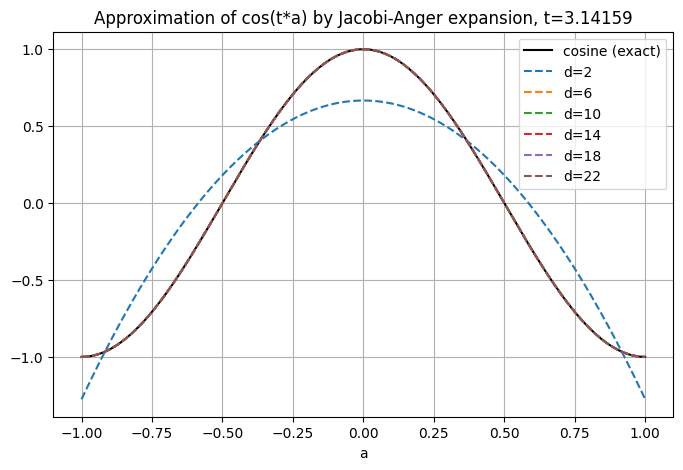

t = 15.70796
[d=2]
max |target| = 0.4589
max |target - exact| = 1.2302e+00
[d=6]
max |target| = 1.2431
max |target - exact| = 1.2015e+00
[d=10]
max |target| = 1.0315
max |target - exact| = 1.3138e+00
[d=14]
max |target| = 1.2563
max |target - exact| = 4.6320e-01
[d=18]
max |target| = 1.0252
max |target - exact| = 3.3173e-02
[d=22]
max |target| = 1.0007
max |target - exact| = 8.1957e-04


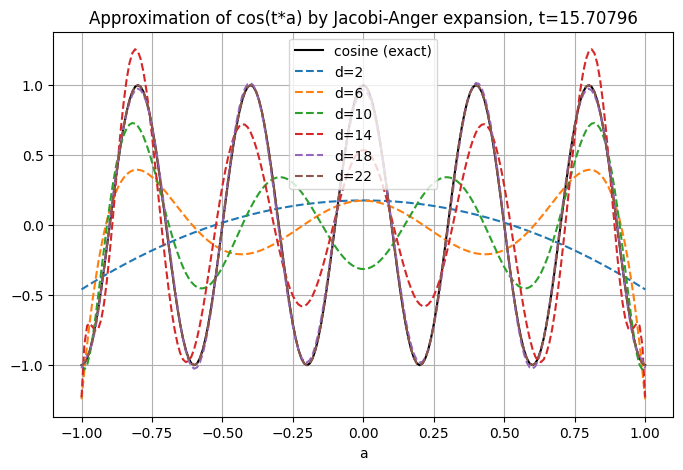

In [4]:
# n次の第1種チェビシェフ多項式 cos(n theta) = T_n(cos(theta)), x = cos(theta)
def chebyshev(n, xvals):
    return np.cos(n * np.arccos(xvals))

def target_cosine_order_d(xvals, t, d):
    r"""
    Jacobi-Anger expansion:
    cos(t * x) = J_0(t) + 2 \sum_{k=1}^\infty (-1)^k J_{2k}(t) T_{2k}(x)
    """
    out = np.zeros_like(xvals, dtype=np.complex128)
    out += complex(sp.N(sp.besselj(0, t)))
    for k in range(1, d//2+1):
        out += 2 * (-1) ** k * complex(sp.N(sp.besselj(2*k, t))) * chebyshev(2*k, xvals)
    return out

import matplotlib.pyplot as plt

# プロット区間（および後でフィッティングを行う区間)の設定
npts = 201
x_min = -1.
x_max = 1.
xgrid = np.linspace(x_min, x_max, npts)

for t in [1*np.pi, 5*np.pi]:
    print(f"t = {t:.5f}")
    y_exact = np.cos(t * xgrid) # 真のコサイン関数の値
    plt.figure(figsize=(8, 5))
    plt.plot(xgrid, y_exact, label="cosine (exact)", color="black")
    for d in range(2, 22+1, 4):
        print(f"[d={d}]")
        # ターゲット関数の値を計算してプロット
        y_target = target_cosine_order_d(xgrid, t, d)
        plt.plot(xgrid, np.real(y_target), label=f"d={d}", linestyle="dashed")
        # ターゲット関数の絶対値の最大値(QSPでは絶対値1以下の関数を近似することが前提)
        print(f"max |target| = {np.max(np.abs(y_target)):.4f}")
        # ターゲット関数と真のコサイン関数の差の絶対値の最大値を計算
        max_diff = np.max(np.abs(y_target - y_exact))
        print(f"max |target - exact| = {max_diff:.4e}")

    plt.xlabel("a")
    plt.title(f"Approximation of cos(t*a) by Jacobi-Anger expansion, t={t:.5f}")
    plt.legend()
    plt.grid()
    plt.show()

$t=\pi$では$d=6$程度で肉眼では区別できないくらい精度の高い展開となっている一方、$t=5\pi$で高精度の展開を行うには$d=20$程度が必要であることがわかる。
コサイン関数を精度$\epsilon$で近似するためには、$d$の大きさ（オーダー）をおおよそ$t + \log(1/\epsilon)$程度にする必要があることが知られている（引用：参考文献[1]）。

それでは、reflection記法を用いたQSPのユニタリ$U_\mathrm{QSP}(\phi_0, ..., \phi_d)$の左上成分である多項式$P(a)$（式(2)を参照）の実部$\mathrm{Re}[P(a)]$を、コサイン関数のJacobi-Anger展開をターゲット関数としてフィットしてみよう。最適化のコスト関数は
$$
\mathrm{cost}(\phi_0, ..., \phi_d) = \sum_{j=1}^{n_\mathrm{pts}} |P(x_j) - f_\mathrm{target}(x_j)|^2
$$
という残差の絶対値の二乗和とし、最適化アルゴリズムには``scipy.optimize.least_squares``関数を用いる。
ここで$x_j$は先ほどのプロットに用いた区間$[-1, 1]$の中の$n_\mathrm{pts}$個のサンプル点で、$f_\mathrm{target}(x_j)$はその点におけるターゲット関数の値である。また、$P(x_j)$は一般に複素数となるので、残差も複素数となることに注意しよう。

In [5]:
# Reflection記法でのQSPの多項式Re[P(a)]を数値的に計算する関数を返す
def make_qsp_function(d, simplify=True):
    phis_sym, U_sym = qsp_unitary_symbolic_Ra_convention(d)
    P_sym = U_sym[0, 0]
    if simplify: # simplifyは時間がかかるので、必要に応じて実行する
        P_sym = sp.simplify(P_sym)
    # 変数の順番は a, phi0, phi1, ..., phid
    P_func = sp.lambdify((a, *phis_sym), P_sym)
    return P_func

# 残差関数の定義（実部・虚部それぞれの差を連結して1つの配列として返す）
def residual(phi):
    global P_func, xgrid, y_target
    y = P_func(xgrid, *phi)
    diff = y - y_target
    return np.concatenate([np.real(diff), np.imag(diff)])

Fitting for d=2...
making P_func takes = 0.0329 s.
least_squares takes = 0.0563 s.
# of function evaluations: 19
max_err = 3.3337e-01, l2_err = 9.8752e-02


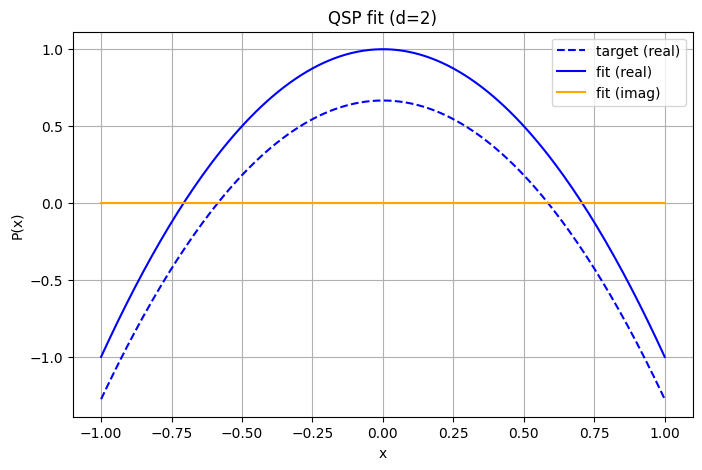

Fitting for d=4...
making P_func takes = 0.0367 s.
least_squares takes = 0.0850 s.
# of function evaluations: 21
max_err = 2.9597e-01, l2_err = 9.7666e-03


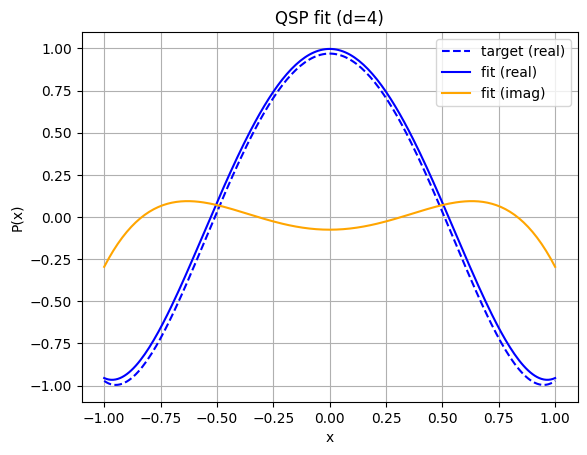

Fitting for d=6...
making P_func takes = 0.2847 s.
least_squares takes = 1.2813 s.
# of function evaluations: 73
max_err = 1.0685e-02, l2_err = 2.7211e-05


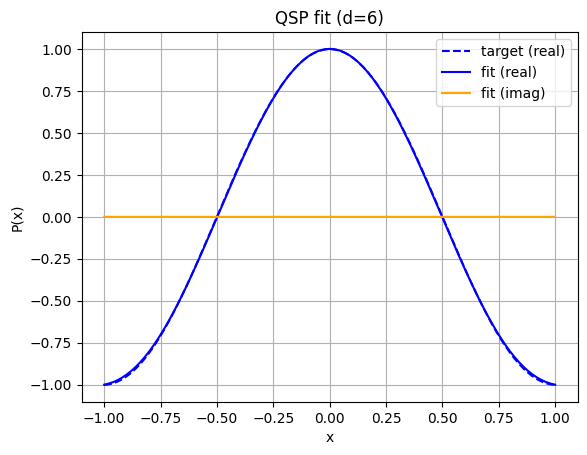

Fitting for d=8...
making P_func takes = 0.3409 s.
least_squares takes = 4.0603 s.
# of function evaluations: 67
max_err = 6.2706e-03, l2_err = 6.6385e-06


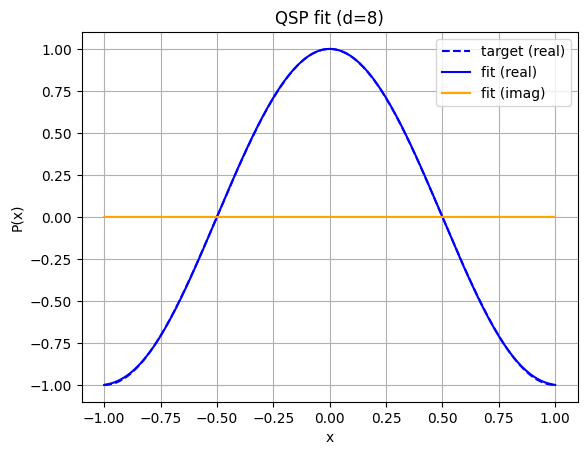

Fitting for d=10...
making P_func takes = 0.9526 s.
least_squares takes = 148.5315 s.
# of function evaluations: 1100
max_err = 2.6352e-03, l2_err = 8.1287e-07


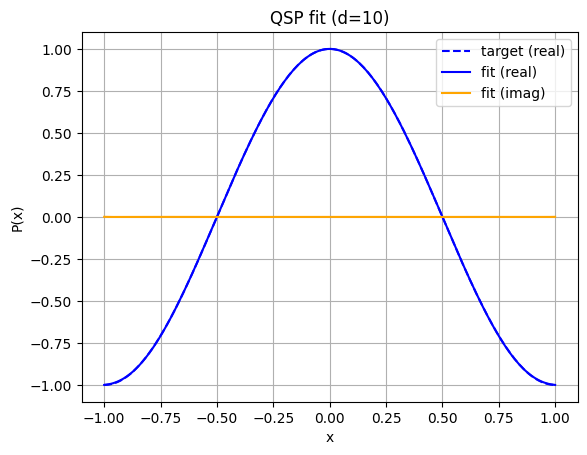

In [6]:
import time
from scipy.optimize import least_squares
seed = 2026
rng = np.random.default_rng(seed)

t = 1. * np.pi
initial_phi = None # 角度の初期値
plt.figure(figsize=(8, 5))
for d in range(2, 10+1, 2):
    print(f"Fitting for d={d}...")
    # ターゲット関数の値を計算
    y_target = target_cosine_order_d(xgrid, t, d)
    # フィットする関数の作成
    time_start = time.time()
    P_func = make_qsp_function(d, simplify=False) # simplifyは時間がかかるので、今回はFalse
    print(f"making P_func takes = {time.time() - time_start:.4f} s.")

    # 初期値の設定
    if initial_phi is None:
        initial_phi = 0.5 * rng.uniform(- np.pi, np.pi, size=d+1)
    else:
        number_of_phis = d + 1 # phi0, phi1, ..., phid の数
        initial_phi = np.concatenate([0.5 * rng.uniform(- np.pi, np.pi, size=number_of_phis - len(initial_phi)), initial_phi]) # ランダムに角度を追加

    # 最適化の実行
    time_start = time.time()
    res = least_squares(residual, initial_phi, method="trf", bounds=(-np.pi, np.pi))
    print(f"least_squares takes = {time.time() - time_start:.4f} s.")
    print("# of function evaluations:", res.nfev)

    # フィットの結果を誤差の指標で評価
    y_fit = P_func(xgrid, *res.x)
    max_err = np.max(np.abs(y_fit - y_target)) # 差の絶対値の最大値
    l2_err = np.mean(np.abs(y_fit - y_target)**2) # 平均二乗誤差
    print(f"max_err = {max_err:.4e}, l2_err = {l2_err:.4e}")

    # フィットの結果をプロット
    plt.plot(xgrid, np.real(y_target), label="target (real)", color="blue", linestyle="dashed")
    plt.plot(xgrid, np.real(y_fit), label="fit (real)", color="blue")
    plt.plot(xgrid, np.imag(y_fit), label="fit (imag)", color="orange")
    plt.xlabel("x")
    plt.ylabel("P(x)")
    plt.title(f"QSP fit (d={d})")
    plt.legend()
    plt.grid()
    plt.show()
    plt.close()

QSPの角度$\phi_0, ..., \phi_d$を適切に選ぶことで、コサイン関数（の有限次数近似）をフィットできていることがわかる。

# 2. 量子特異値変換と量子ダイナミクスシミュレーションへの応用
書籍の4.3節で説明したブロック符号化や量子ビット化とQSPを組み合わせることで、さまざまな量子アルゴリズムを統一的に理解できるようになる。これは量子特異値変換（Quantum Singular Value Transformation, QSVT）と呼ばれるフレームワークで、量子アルゴリズムの設計や解析に役立つ非常に強力なツールとなる。ここではQSVTの基本的なアイデアと、それがどのように量子ダイナミクスのシミュレーションに応用できるかを説明しよう。

## 2.1 量子特異値変換の基本的なアイデア
書籍の(4.36)式と同様に、ハミルトニアン$H$の固有値の1つを$\lambda$、対応する固有状態を$|\lambda\rangle_s$としたとき（$s$はシステム量子ビットを表す添字である）、以下の2つの互いに直交する状態
$$
|0^\lambda\rangle = {|0...0\rangle}_a {|\lambda\rangle}_s, \:\:
|\perp^\lambda\rangle = \frac{\lambda - U_\mathrm{LCU}}{\sqrt{1 - \lambda^2}} |0^\lambda\rangle
$$
を定義する。ここで$U_\mathrm{LCU}$は、書籍の(4.23)式で定義されるLinear Combination of Unitaries (LCU)を用いた$H$のブロック符号化であり、補助量子ビットの状態$|0...0\rangle_a$に対して${}_a \langle 0...0|U_\mathrm{LCU}|0...0\rangle_a = H$を満たす。

書籍の(4.41)式の直後でも説明したように、LCUの定義（(4.23)式）より$U_\mathrm{LCU}^2$は恒等演算子$I$になる。よって、$\{|0^\lambda\rangle, |\perp^\lambda\rangle\}$を基底とする2次元部分空間
$$
\mathcal{V}_\lambda = \mathrm{span}\{|0^\lambda\rangle, |\perp^\lambda\rangle\}
$$
に対して$U_\mathrm{LCU}$の作用は閉じている（$|\perp^\lambda\rangle$は$|0^\lambda\rangle$と$U_\mathrm{LCU}|0^\lambda\rangle$の線型結合であることに注意）。
この2次元部分空間において、$\{|0^\lambda\rangle, -|\perp^\lambda\rangle\}$を基底として$U_\mathrm{LCU}$を行列表示すると、以下の$2\times 2$行列になる（証明は量子ビット化の演算子$W_H$の行列表示(4.37)(4.38)式の導出と同様なので、ここでは省略する。また、QSPとの対応を見やすくするために基底の1つに$-|\perp^\lambda\rangle$を用いていることに注意）。
$$
\begin{pmatrix} \lambda & \sqrt{1 - \lambda^2} \\ \sqrt{1 - \lambda^2} & -\lambda \end{pmatrix}
$$      
つまり、2次元部分空間$\mathcal{V}_\lambda$内で適切な基底をとって表示すると、$U_\mathrm{LCU}$はreflection記法でのQSPのゲート$R_\lambda$と一致する。

一方で、2次元部分空間$\mathcal{V}_\lambda$の同じ基底で表示したとき、reflection記法でのQSPのゲート$S_z(\phi)$に一致するゲートを作ることもできる。
つまり、作用が$\mathcal{V}_\lambda$内で閉じており、$|0^\lambda\rangle$には位相$e^{i\phi}$をかけ、$-|\perp^\lambda\rangle$には位相$e^{-i\phi}$をかけるゲートを構成できるのだ。
具体的には、補助量子ビットの状態が$|0...0\rangle_a$のときに位相$e^{i\phi}$をかけ、それ以外のときに位相$e^{-i\phi}$をかけるゲートとして実装すれば良い（理由：$H$の全ての固有状態$|\lambda'\rangle$に対して、$|\perp^\lambda\rangle$は$|0^{\lambda'} \rangle = |0...0\rangle_a |{\lambda'} \rangle_s$と直交している。よって$|\perp^\lambda\rangle$は補助量子ビット部分が必ず$|0...0\rangle_a$以外である状態の重ね合わせになっている）。
このゲートは、以下の図1（表示されない場合は[画像ファイル](./4.3_補足_Sz回路図.png)を参照）のように追加の補助量子ビットを1つ用いた多重制御NOTゲートを使って実装できる。このゲートを$\widetilde{S}_z(\phi)$と呼ぶことにする
（なお、$\widetilde{S}_z(\phi)$は$\lambda$に依存しないことに注意しよう）。

<img src="./4.3_補足_Sz回路図.png" alt="4.3_補足_Sz回路図.png" width="40%">

*図1: $\widetilde{S}_z(\phi)$を実装する量子回路。$|q_0\rangle_a, ..., |q_{m-1}\rangle_a$はブロック符号化に用いる$m$個の補助量子ビットで、$|0\rangle_{a'}$は追加の補助量子ビットである。パウリ$Z$回転ゲートの定義より$R_Z(2\phi)=e^{-i\phi Z}$であることに注意しよう。*


以上より、$U_\mathrm{LCU}$と$\widetilde{S}_z(\phi_0), ..., \widetilde{S}_z(\phi_d)$を交互に用いた
$$
\widetilde{U} = \widetilde{S}_z(\phi_0) U_\mathrm{LCU} \widetilde{S}_z(\phi_1) U_\mathrm{LCU} ... U_\mathrm{LCU} \widetilde{S}_z(\phi_d) \tag{3}
$$
というユニタリを考えると、これを二次元部分空間$\mathcal{V}_\lambda$の基底$\{|0^\lambda\rangle, -|\perp^\lambda\rangle\}$で表示したものはreflection記法でのQSPのユニタリ$U_\mathrm{QSP}(\phi_0, ..., \phi_d)$（式(2)）と全く同じ表式を持つことになり、$2\times 2$行列の左上成分、つまり$\langle 0^\lambda| \widetilde{U} |0^\lambda\rangle$は$\lambda$の多項式$P(\lambda)$になる。

$H$の全ての固有値$\lambda$に対して同じことが成り立つので、これは
$$
_a\langle 0...0| \widetilde{U} |0...0\rangle_a = \sum_\lambda P(\lambda) |\lambda\rangle_s \langle \lambda|_s = P(H)
$$
を意味している。
つまり、**$\widetilde{U}$は$H$の多項式$P(H)$のブロック符号化**になっているのだ。
$P(H)$の固有値は$P(\lambda)$だから、QSPで用いる関数を適切に選べば、$H$の固有値をさまざまに変換した$P(H)$のブロック符号化を実現できる。
これがQSVT（量子**特異値変換**）の基本的なアイデアである*。

_\* 正確には、QSVTは今回考えたようなエルミート行列$H$だけでなく、特異値$\sigma$を持つ（正方行列に限らない）一般の行列$A$に対して適用できる。この場合は、変換された特異値$P(\sigma)$を持つ行列のブロック符号化を構成することができる。_

整理すると、QSVTをハミルトニアン$H$に適用する場合の流れは以下の通りである。
1. 固有値を変換する関数$f(\lambda)$、あるいはブロック符号化したい$H$の多項式$f(H)$を選ぶ。
2. 関数$f(a)$を（近似的に）実現するようなQSPの角度$\phi_0, ..., \phi_d$を求める。つまり、式(2)の$P(a)$が$f(a)$を近似するような$\phi_0, ..., \phi_d$を求める。
3. 角度$\phi_0, ..., \phi_d$を用いて、式(3)のユニタリ$\widetilde{U}$を実装する。これが$f(H)$のブロック符号化（の近似）になる。

## 2.2 QSVTの量子ダイナミクスシミュレーションへの適用
QSVTを用いることで、グローバーのアルゴリズムや量子位相推定アルゴリズムなど、既存の様々な量子アルゴリズムを統一的に理解できることが知られている。ここではQSVTの量子ダイナミクスシミュレーションへの応用を紹介する。

量子ダイナミクスシミュレーションの目的の1つは、ハミルトニアン$H$によって時間発展した状態$|\psi(t)\rangle_s = e^{-iHt}|\psi_0\rangle_s$を得ることである（$|\psi_0\rangle_s$は初期状態）。
仮にQSVTによって$f(H) = e^{-iHt}$のブロック符号化$_a \langle 0...0| U_t |0...0\rangle_a = e^{-iHt}$を実現できたとしよう。すると、システム量子ビットと補助量子ビットを合わせた全系の初期状態$|0...0\rangle_a |\psi_0\rangle_s$に対して$U_t$を作用させた後、補助量子ビットを測定して$|0...0\rangle_a$が得られたときのシステム量子ビットの状態は、時間発展した状態$e^{-iHt}|\psi_0\rangle_s$となる*。

_\*時間発展演算子$e^{-iHt}$はそもそもユニタリであるので、もし完全なブロック符号化が実現できたとすると、補助量子ビットを測定して$|0...0\rangle_a$となる確率は1となる（書籍の(4.21)式の下で説明したように、測定の成功確率はブロック符号化された演算子を作用させた状態のノルム $\|e^{-iHt} |\psi_0\rangle_s \|^2 = 1$である）。_

しかし、前述したようにQSPで実現可能な多項式$P(a)$は繰り返しの回数$d$の偶奇に応じて$a$の偶関数か奇関数に限られるという制約があり、時間発展演算子$e^{-iHt}$に対応する関数$f(a)=e^{-ita}$を直接実現することは簡単ではない。
そこで、以下の2つの関数（それぞれ$a$の偶関数と奇関数）に対してQSPを行う。
$$
f_1(a) = \cos(ta), \:\: f_2(a) = \sin(ta)
$$
これらのQSPの結果を用いた量子回路（式(3)）は、
$$
\begin{align}
P_1(H) &= \mathrm{Re}[\exp(i Ht)] = \cos(Ht) = \sum_{k=0}^\infty \frac{(-1)^k t^{2k}}{(2k)!} H^{2k} =\sum_\lambda \cos(t \lambda) |\lambda\rangle_s \langle \lambda|_s, \\
P_2(H) &= \mathrm{Im}[\exp(i Ht)] = \sin(Ht) = \sum_{k=0}^\infty \frac{(-1)^k t^{2k+1}}{(2k+1)!} H^{2k+1} =\sum_\lambda \sin(t \lambda) |\lambda\rangle_s \langle \lambda|_s
\end{align}
$$
のブロック符号化となっている。
それぞれの量子回路を$\widetilde{U}_{\cos}, \widetilde{U}_{\sin}$と呼ぶことにしよう。

以下の図2のようなアダマールテスト型の量子回路を用いると、アダマールテスト用の補助量子ビットの測定結果が$0,1$ の時に、補助量子ビットとシステム量子ビットを合わせた全系の状態は
$$
\left( \widetilde{U}_{\cos} \pm i \widetilde{U}_{\sin} \right) |0...0\rangle_a |\psi_0\rangle_s
$$
に比例するものになる（図が表示されない場合は[画像ファイル](./4.3_補足_アダマールテスト型回路.png)を参照）。

<img src="./4.3_補足_アダマールテスト型回路.png" alt="4.3_補足_アダマールテスト型回路.png" width="60%">

*図2: 量子ダイナミクスシミュレーションを行うためのアダマールテスト型の量子回路。アダマールテスト用の補助量子ビット（添字Had）の測定結果が$0$であるか$1$であるかに応じて、全系の状態が$\left( \widetilde{U}_{\cos} \pm i \widetilde{U}_{\sin} \right) |0...0\rangle_a |\psi_0\rangle_s$に比例したものに変化する。*

この状態の補助量子ビットを測定して$|0...0\rangle_a$が得られたときのシステム量子ビットの状態は、
$$
\left(\cos(Ht) \pm i \sin(Ht) \right) |\psi_0\rangle_s = e^{\pm iHt}|\psi_0\rangle_s
$$
に比例するものになる。
つまり、アダマールテストの測定結果が$1$であるような場合を取り出せば$e^{-iHt}$のブロック符号化が実現でき、量子ダイナミクスシミュレーションの目標である状態$e^{- iHt}|\psi_0\rangle_s$を作り出せるのだ。これが、QSVTを用いた量子ダイナミクスシミュレーションの実行方法である。


### 注：実装に必要な量子ゲート数について
最後に、この手法による量子ダイナミクスシミュレーションの精度と必要な量子ゲート数について簡単に説明しておこう（書籍のP132の脚注22も参照）。

前述したように、Jacobi-Anger展開を用いて$\cos(ta)$を精度$\epsilon$で近似するためには、展開の次数$k = \frac{d}{2}$を$t + \log(1/\epsilon)$程度の大きさ（オーダー）にすれば十分であることが知られている。
そして、$k=\frac{d}{2}$次の展開式（つまり$a$の$d$次の多項式）は、基本的には繰り返し回数が$d$回のQSPによって実現できる。
ゆえに、$\cos(Ht)$を精度$\epsilon$で近似するためには、$U_\mathrm{LCU}$と$\widetilde{S}_z(\phi)$を$2(t + \log(1/\epsilon))$回程度用いた$\widetilde{U}$を実装すれば十分であることになる（オーダーの議論なので、係数2に意味はないことに注意）。$\sin(Ht)$についても同様のことが言えて、結局、時間発展演算子$e^{-iHt}$を精度$\epsilon$で近似するためには$U_\mathrm{LCU}$と$\widetilde{S}_z(\phi)$を$t + \log(1/\epsilon)$回程度用いる必要があることが言える。

一方で、書籍の4.2節で紹介した1次のトロッター分解を用いた量子ダイナミクスシミュレーションでは、精度$\epsilon$の近似を実現するには微小な時間発展$e^{-iH\Delta t}$を$O(t^2/\epsilon)$回行う必要がある。この意味（$\epsilon$依存性）で、QSVTを用いた方法は、トロッター分解を用いた方法に比べて、量子ダイナミクスシミュレーションに必要な量子ゲート数のスケーリングを大幅に（指数関数的に）改善できることになる。ただし、ここでは$U_\mathrm{LCU}, \widetilde{S}_z(\phi)$の実行回数と$e^{-iH\Delta t}$の実行回数を比較しており、これらを基本的な量子ゲートで実現した時の詳細なゲート数については考慮していないことに注意しよう。また、QSVTを用いた方法では補助量子ビットが必要であることにも留意しよう。

# 3. 実装例
最後に、QSVT（ブロック符号化とQSP）を用いた量子ダイナミクスシミュレーションを具体的なハミルトニアンを使って実装してみよう。
[量子ビット化の補足ノート](./4.3_補足_量子ビット化.ipynb)と同様に、2量子ビットのハミルトニアン
$$
H = c_0 X_0 + c_1 Z_0 + c_2 X_0 X_1 + c_3 Z_0 Z_1
$$
を考える。ここで、$c_0,c_1,c_2,c_3$は実数の係数で、簡単のため全て正であると仮定する。
また、規格化された
$$ H ' = \frac{H}{\alpha} = p_{00} X_0 + p_{01} Z_0 + p_{10} X_0 X_1 + p_{11} Z_0 Z_1
$$
も定義する。
$\alpha = c_0 + c_1 + c_2 + c_3$は正の定数で、$p_{00} = c_0 / \alpha, p_{01} = c_1 / \alpha, p_{10} = c_2 / \alpha, p_{11} = c_3 / \alpha$と定義した。
係数の和が$p_{00} + p_{01} + p_{10} + p_{11} = 1$であることに注意しよう。

LCUの構成方法より、ブロック符号化が行われるのは規格化されたハミルトニアン$H'$の方である。書籍のP128の脚注17にもあるように、$e^{-iHt} = e^{-i\alpha H't}$だから、元のハミルトニアン$H$に対して時間$t$のダイナミクスをシミュレートすることは、規格化されたハミルトニアン$H'$に対して時間$t' = \alpha t$のダイナミクスをシミュレートすることに対応する。

## 3.1 量子回路の準備
まずは$R_\lambda$に相当する、$U_\mathrm{LCU}$を実装しよう。[量子ビット化の補足ノート](4.3_補足_量子ビット化.ipynb)と同様なので詳細な説明は省略する。今回は、$\widetilde{S}_z(\phi)$の実装（図1）のために量子ビットを1つ追加して、合計で5つの量子ビットを用いる。

In [7]:
from quri_parts.circuit import QuantumCircuit
from quri_parts.core.state import quantum_state, apply_circuit
from quri_parts.qulacs.simulator import evaluate_state_to_vector
from quri_parts.circuit.utils.circuit_drawer import draw_circuit

# 量子ビットの数とインデックスの定義
n_qubits = 5  # 0,1がシステムの量子ビット、2,3がLCU用の補助量子ビット, 4が\widetilde{S}_zの実装に使う追加量子ビット
sys_0, sys_1 = 0, 1 # システム量子ビットのインデックス
anc_0, anc_1 = 2, 3 # 補助量子ビットのインデックス
anc_Sz = 4 # \widetilde{S}_zの実装に使う追加量子ビットのインデックス

# ハミルトニアンの係数
c0 = 1
c1 = 2
c2 = 3
c3 = 4

# 係数の規格化
alpha = c0 + c1 + c2 + c3
if alpha <= 0:
    raise ValueError("c0+c1+c2+c3 must be positive.")
if min(c0, c1, c2, c3) < 0:
    raise ValueError("This simple sample assumes c0,c1,c2,c3 >= 0.")

p00, p01, p10, p11 = c0 / alpha, c1 / alpha, c2 / alpha, c3 / alpha

def build_prepare_2anc(p00: float, p01: float, p10: float, p11: float, n_qubits, anc_0, anc_1) -> QuantumCircuit:
    # First qubit rotation
    theta0 = 2 * np.arccos(np.sqrt(p00 + p10))

    # Conditional second-qubit rotations
    theta1_if_q0_0 = 2 * np.arccos(np.sqrt(p00 / (p00 + p10)))
    theta1_if_q0_1 = 2 * np.arccos(np.sqrt(p01 / (p01 + p11)))

    # 2つのRY回転ゲートを用いた制御RYゲートの実装
    phi = 0.5 * (theta1_if_q0_0 + theta1_if_q0_1)
    psi = 0.5 * (theta1_if_q0_0 - theta1_if_q0_1)

    # PREP_aの回路を構築
    circ = QuantumCircuit(n_qubits)
    circ.add_RY_gate(anc_0, theta0)
    circ.add_RY_gate(anc_1, phi)
    circ.add_CNOT_gate(anc_0, anc_1)
    circ.add_RY_gate(anc_1, psi)
    circ.add_CNOT_gate(anc_0, anc_1)

    return circ

def add_ccz(circ: QuantumCircuit, control0: int, control1: int, target: int) -> None:
    """多重制御ZゲートCCZの実装.
    アダマールゲートHについて HXH = Z であることを利用して、トフォリゲートCCXをCCZに変換している。"""
    circ.add_H_gate(target)
    circ.add_TOFFOLI_gate(control0, control1, target)
    circ.add_H_gate(target)
    return None

def build_select(n_qubits, anc_0, anc_1, sys_0, sys_1) -> QuantumCircuit:
    r"""  以下のユニタリを実装する。
      |00><00| \otimes X0   + |01><01| \otimes Z0
    + |10><10| \otimes X0X1 + |11><11| \otimes Z0Z1
    """
    circ = QuantumCircuit(n_qubits)

    # 補助ビットが00のときにX0を適用
    circ.add_X_gate(anc_0)
    circ.add_X_gate(anc_1)
    circ.add_TOFFOLI_gate(anc_0, anc_1, sys_0)
    circ.add_X_gate(anc_0)
    circ.add_X_gate(anc_1)

    # 補助ビットが01のときにZ0を適用
    circ.add_X_gate(anc_1)
    add_ccz(circ, anc_0, anc_1, sys_0)
    circ.add_X_gate(anc_1)

    # 補助ビットが10のときにX0X1を適用
    circ.add_X_gate(anc_0)
    circ.add_TOFFOLI_gate(anc_0, anc_1, sys_0)
    circ.add_TOFFOLI_gate(anc_0, anc_1, sys_1)
    circ.add_X_gate(anc_0)

    # 補助ビットが11のときにZ0Z1を適用
    add_ccz(circ, anc_0, anc_1, sys_0)
    add_ccz(circ, anc_0, anc_1, sys_1)

    return circ

# U_LCUの実装
from quri_parts.circuit import inverse_circuit
U_select = build_select(n_qubits=n_qubits, anc_0=anc_0, anc_1=anc_1, sys_0=sys_0, sys_1=sys_1)
U_prep = build_prepare_2anc(p00, p01, p10, p11, n_qubits=n_qubits, anc_0=anc_0, anc_1=anc_1)

U_lcu = QuantumCircuit(n_qubits)
U_lcu.extend(U_prep)
U_lcu.extend(U_select)
U_lcu.extend(inverse_circuit(U_prep))

次にQSPの$S_z(\phi)$に相当するゲート、つまり全系でのゲート$\widetilde{S}_z(\phi)$を実装しよう。今回は、補助量子ビットが$|00\rangle_a$であるような状態には位相$e^{i\phi}$を、それ以外には位相$e^{-i\phi}$をかけるゲートとなる。
これは前述の図1のように追加の補助量子ビットを1つ用いて次のように実装できる。

In [8]:
# \widetilde{S}_z(\phi)の実装.
def add_Sz(circuit: QuantumCircuit, anc_0: int, anc_1: int, anc_Sz: int, phi: float) -> QuantumCircuit:
    """ |00>_a には位相 e^{i*phi} を、それ以外には位相 e^{-i*phi} をかける """
    circuit.add_X_gate(anc_0)
    circuit.add_X_gate(anc_1)
    circuit.add_TOFFOLI_gate(anc_0, anc_1, anc_Sz)
    circuit.add_RZ_gate(anc_Sz, 2*phi)
    circuit.add_TOFFOLI_gate(anc_0, anc_1, anc_Sz)
    circuit.add_X_gate(anc_0)
    circuit.add_X_gate(anc_1)
    return None

# サンプルとしてテキトーな角度を使った \widetilde{S}_z を用意
circ_Sz = QuantumCircuit(n_qubits)
sample_angle = 0.23 * np.pi
add_Sz(circ_Sz, anc_0, anc_1, anc_Sz, phi=sample_angle)
draw_circuit(circ_Sz)

                                                                                
                                                                                
--------------------------------------------------------------------------------
                                                                                
                                                                                
                                                                                
--------------------------------------------------------------------------------
                                                                                
          ___                                                             ___   
         | X |                                                           | X |  
---------|0  |-------------●-------------------------------●-------------|5  |--
         |___|             |                               |             |___|  
   ___                     |

$|0^\lambda\rangle$と$-|\perp^\lambda\rangle$を数値的に直接計算して、$U_\mathrm{LCU}$と$\widetilde{S}_z$の行列表現を確認してみよう。

In [9]:
def matrix_from_circuit(circuit: QuantumCircuit, n_qubits: int) -> np.ndarray:
    """ Return the full unitary matrix of a circuit by acting on basis states. """
    dim = 2**n_qubits
    mat = np.zeros((dim, dim), dtype=complex)
    for j in range(dim):
        state = quantum_state(n_qubits, bits=j) # 入力状態は|j>
        # 状態ベクトルを数値計算
        mat[:, j] = evaluate_state_to_vector(apply_circuit(circuit, state)).vector
    return mat

# U_LCUと\widetilde{S}_zの行列要素を数値的に計算
mat_U_lcu = matrix_from_circuit(U_lcu, n_qubits=n_qubits)
mat_Sz = matrix_from_circuit(circ_Sz, n_qubits=n_qubits)

# H'の固有状態を計算
from quri_parts.core.operator import Operator, get_sparse_matrix, pauli_label
H = Operator(
    {
        pauli_label("X0"): c0,
        pauli_label("Z0"): c1,
        pauli_label("X0 X1"): c2,
        pauli_label("Z0 Z1"): c3,
    }
)
H_mat = get_sparse_matrix(H).toarray()
H_prime_mat = H_mat / alpha
eigs, vecs = np.linalg.eigh(H_prime_mat)

# H'の各固有状態に対して、|0^lambda>と|perp^lambda>を定義して行列要素を確認
for i in range(len(eigs)):
    eig = eigs[i]
    print(f"--- {i}番目の固有値: {eig} ---")
    # |0^lambda>の定義
    state_0_lambda = np.zeros(2**n_qubits, dtype=complex)
    state_0_lambda[:len(eigs)] = vecs[:, i]
    # |perp^lambda>の定義
    state_perp_lambda = (eig * state_0_lambda - mat_U_lcu @ state_0_lambda) / np.sqrt(1 - eig**2)
    print("|perp^lambda>のノルム:", np.linalg.norm(state_perp_lambda)) # ノルムの確認
    print("内積 <0^lambda|perp^lambda>:", np.vdot(state_0_lambda, state_perp_lambda)) # 直交性の確認
    # U_LCUの行列要素を確認
    matrix_element_00 =  np.vdot(state_0_lambda, mat_U_lcu @ state_0_lambda)
    matrix_element_0p = -np.vdot(state_0_lambda, mat_U_lcu @ state_perp_lambda)
    matrix_element_p0 = -np.vdot(state_perp_lambda, mat_U_lcu @ state_0_lambda)
    matrix_element_pp =  np.vdot(state_perp_lambda, mat_U_lcu @ state_perp_lambda)
    mat_U_lcu_qubitization_basis = np.array([[matrix_element_00, matrix_element_0p], [matrix_element_p0, matrix_element_pp]])
    # S_zの行列要素も確認
    matrix_element_Sz_00 =  np.vdot(state_0_lambda, mat_Sz @ state_0_lambda)
    matrix_element_Sz_0p = -np.vdot(state_0_lambda, mat_Sz @ state_perp_lambda)
    matrix_element_Sz_p0 = -np.vdot(state_perp_lambda, mat_Sz @ state_0_lambda)
    matrix_element_Sz_pp =  np.vdot(state_perp_lambda, mat_Sz @ state_perp_lambda)
    mat_Sz_qubitization_basis = np.array([[matrix_element_Sz_00, matrix_element_Sz_0p], [matrix_element_Sz_p0, matrix_element_Sz_pp]])
    print("U_LCUの行列要素:")
    print(mat_U_lcu_qubitization_basis)
    print("理論上のU_LCUの行列表示:")
    print(np.array([[eig, np.sqrt(1 - eig**2)], [np.sqrt(1 - eig**2), -eig]]))
    print(r"\widetilde{S}S_zの行列要素:")
    print(mat_Sz_qubitization_basis)
    print(r"理論上の\widetilde{S}_zの行列表示:")
    print(np.array([[np.exp(1j*sample_angle), 0], [0, np.exp(-1j*sample_angle)]]))


--- 0番目の固有値: -0.771115035032468 ---
|perp^lambda>のノルム: 0.9999999999999989
内積 <0^lambda|perp^lambda>: (-4.961601228509711e-16+0j)
U_LCUの行列要素:
[[-0.77111504+0.j  0.63669585-0.j]
 [ 0.63669585-0.j  0.77111504+0.j]]
理論上のU_LCUの行列表示:
[[-0.77111504  0.63669585]
 [ 0.63669585  0.77111504]]
\widetilde{S}S_zの行列要素:
[[7.5011107e-01+6.61311865e-01j 3.7217520e-16+3.28116576e-16j]
 [3.7217520e-16+3.28116576e-16j 7.5011107e-01-6.61311865e-01j]]
理論上の\widetilde{S}_zの行列表示:
[[0.75011107+0.66131187j 0.        +0.j        ]
 [0.        +0.j         0.75011107-0.66131187j]]
--- 1番目の固有値: -0.07335940803247587 ---
|perp^lambda>のノルム: 0.9999999999999992
内積 <0^lambda|perp^lambda>: (4.433595624936884e-17+0j)
U_LCUの行列要素:
[[-0.07335941+0.j  0.99730557-0.j]
 [ 0.99730557-0.j  0.07335941+0.j]]
理論上のU_LCUの行列表示:
[[-0.07335941  0.99730557]
 [ 0.99730557  0.07335941]]
\widetilde{S}S_zの行列要素:
[[ 7.50111070e-01+6.61311865e-01j -3.32568916e-17-2.93198939e-17j]
 [-3.32568916e-17-2.93198939e-17j  7.50111070e-01-6.61311865e-01j]]


$H'$（あるいは$H$）の固有状態によって定義される2次元部分空間$\mathcal{V}_\lambda$の中で適切な基底をとることで、$U_\mathrm{LCU}$と$\widetilde{S}_z$の行列表示がQSPの各ゲートと一致していることがわかる。

## 3.2 量子ダイナミクスシミュレーションの実装
それでは、1.3節のQSPの実装で行ったコサイン関数のフィッティングによって得られた角度$\phi_0, ..., \phi_d$を使って式(3)の量子回路$\widetilde{U}$を作成し、それが$\cos(H't)$のブロック符号化を（近似的に）実現していることを確認してみよう。

In [10]:
print(f"d={d}")
phis_fit = res.x

# QSPの角度を使って\widetilde{U}（式(3)）の量子回路を作成
circ_tilde_U = QuantumCircuit(n_qubits)
add_Sz(circ_tilde_U, anc_0, anc_1, anc_Sz, phis_fit[0])
for i in range(1, len(phis_fit)):
    circ_tilde_U.extend(U_lcu)
    add_Sz(circ_tilde_U, anc_0, anc_1, anc_Sz, phis_fit[i])

# 行列要素を数値的に計算
circ_tilde_U_mat = matrix_from_circuit(circ_tilde_U, n_qubits)
print("Re(<00|U_QSP|00>) =") # _a<00|U_QSP|00>_aの行列要素を表示
print(circ_tilde_U_mat[0:4, 0:4].real)

# cos(H'*t) = Re[exp(i*H'*t)] と比較
from scipy.linalg import expm
cos_Hpt_mat = expm(1j * H_prime_mat * t).real
print("Re(cos(H'*t)) =")
print(cos_Hpt_mat)

print("difference =")
print(circ_tilde_U_mat[0:4, 0:4].real - cos_Hpt_mat)


d=10
Re(<00|U_QSP|00>) =
[[-3.59061277e-01 -1.25986944e-16 -1.75860699e-01 -7.03442795e-01]
 [ 1.25986944e-16 -3.59061277e-01  7.03442795e-01 -1.75860699e-01]
 [-1.75860699e-01  7.03442795e-01  5.78862449e-01 -6.93046635e-17]
 [-7.03442795e-01 -1.75860699e-01  6.93046635e-17  5.78862449e-01]]
Re(cos(H'*t)) =
[[-3.58100920e-01 -5.55111512e-17 -1.75751064e-01 -7.03004255e-01]
 [-1.56125113e-17 -3.58100920e-01  7.03004255e-01 -1.75751064e-01]
 [-1.75751064e-01  7.03004255e-01  5.79238086e-01  0.00000000e+00]
 [-7.03004255e-01 -1.75751064e-01 -2.08166817e-17  5.79238086e-01]]
difference =
[[-9.60356858e-04 -7.04757930e-17 -1.09635024e-04 -4.38540097e-04]
 [ 1.41599456e-16 -9.60356858e-04  4.38540097e-04 -1.09635024e-04]
 [-1.09635024e-04  4.38540097e-04 -3.75636729e-04 -6.93046635e-17]
 [-4.38540097e-04 -1.09635024e-04  9.01213452e-17 -3.75636729e-04]]


$\cos(H't)$のブロック符号化が近似的に実現できていることがわかる。

最後に、時間$t$を変えて量子ダイナミクスを計算してみよう。
ここでは簡単のため、人工的ではあるが $|\psi(t)\rangle = e^{-iHt} |00\rangle_s$ に対して、$r(t) = \mathrm{Re}\left[ _s \langle \psi(0) | \psi(t) \rangle_s \right] = \mathrm{Re}\left[ _s \langle 00 | e^{-iHt} | 00 \rangle_s \right]$ という量を計算する。つまり、時間発展した状態$|\psi(t)\rangle_s$と初期状態$|\psi(0)\rangle_s$との重なり（内積）の"実部"が、どのように時間変化するかを見てみる。


_\*もちろん前述したように、サイン関数をターゲットとしたQSPを実行して$\sin(H't)$のブロック符号化を実装し、図3のアダマールテスト型の量子回路を用いることで$|\psi(t)\rangle_s$を得ることができるから、一般の物理量$O_s$の期待値$_s \langle \psi(t) | O_s | \psi(t) \rangle_s$ を計算することも可能である。_

t = 0.00
cost = 0.0000, max_err = 6.8857e-08, l2_err = 1.9171e-15
t = 0.05
cost = 0.0421, max_err = 1.2242e-01, l2_err = 4.1878e-04
t = 0.10
cost = 0.5935, max_err = 4.5970e-01, l2_err = 5.9054e-03
t = 0.15
cost = 2.4252, max_err = 9.2926e-01, l2_err = 2.4131e-02
t = 0.20
cost = 0.9947, max_err = 5.8678e-01, l2_err = 9.8978e-03
t = 0.25
cost = 0.1121, max_err = 1.9908e-01, l2_err = 1.1152e-03
t = 0.30
cost = 0.0003, max_err = 1.0033e-02, l2_err = 2.8178e-06
t = 0.35
cost = 0.0114, max_err = 6.3653e-02, l2_err = 1.1336e-04
t = 0.40
cost = 0.3379, max_err = 3.4674e-01, l2_err = 3.3626e-03
t = 0.45
cost = 1.7965, max_err = 7.9031e-01, l2_err = 1.7875e-02
t = 0.50
cost = 1.4261, max_err = 7.1355e-01, l2_err = 1.4190e-02
t = 0.55
cost = 0.2253, max_err = 2.8503e-01, l2_err = 2.2417e-03
t = 0.60
cost = 0.0110, max_err = 2.6935e-02, l2_err = 1.0918e-04
t = 0.65
cost = 0.0266, max_err = 2.9257e-02, l2_err = 2.6505e-04
t = 0.70
cost = 0.1539, max_err = 2.0394e-01, l2_err = 1.5309e-03
t = 0.75
c

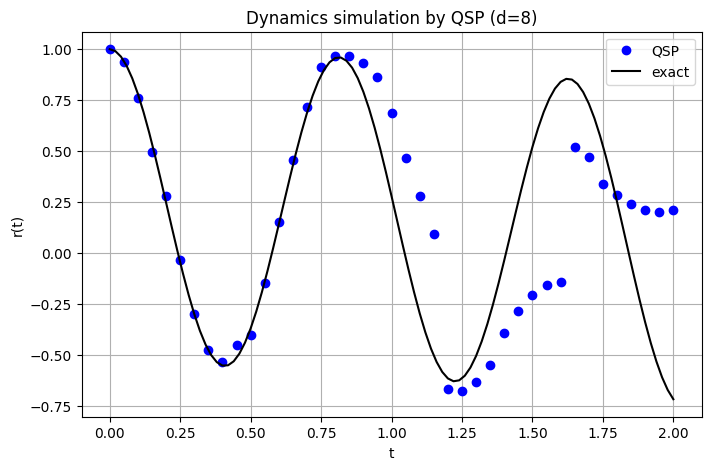

In [11]:
d = 8 # 環境によっては時間がかかるのでその場合はdを小さくして試してほしい
t_end = 2.
t_list = np.linspace(0, t_end, 40+1)
r_t_list = []

time_start = time.time()
# コサイン関数のd次の近似 (simplifyすることで関数を単純にし実行時間の削減を企図)
P_func = make_qsp_function(d, simplify=True)
initial_phi = None # 角度の初期値
for t in t_list:
    print(f"t = {t:.2f}")
    # H' = H/alpha なので時間 t' = t * alpha を使う
    t_prime = t * alpha
    # QSPを実行
    y_target = target_cosine_order_d(xgrid, t_prime, d)

    if initial_phi is None:
        initial_phi = 1. * rng.uniform(- np.pi, np.pi, size=d+1)
    res = least_squares(residual, initial_phi, method="trf", bounds=(-np.pi, np.pi))

    # フィットの結果を誤差の指標で評価
    y_fit = P_func(xgrid, *res.x)
    max_err = np.max(np.abs(y_fit - y_target)) # 差の絶対値の最大値
    l2_err = np.mean(np.abs(y_fit - y_target)**2) # 平均二乗誤差
    print(f"cost = {res.cost:.4f}, max_err = {max_err:.4e}, l2_err = {l2_err:.4e}")

    initial_phi = res.x # 角度の初期値を更新

    # QSPの角度を使って回路を作成
    phis_fit = res.x
    circ_qsp = QuantumCircuit(n_qubits)
    add_Sz(circ_qsp, anc_0, anc_1, anc_Sz, phis_fit[0])
    for i in range(1, len(phis_fit)):
        circ_qsp.extend(U_lcu)
        add_Sz(circ_qsp, anc_0, anc_1, anc_Sz, phis_fit[i])

    # 量子回路を実行
    state_0 = quantum_state(n_qubits, bits=0) # 全系の初期状態|00000>
    state_t = apply_circuit(circ_qsp, state_0)
    state_t_vec = evaluate_state_to_vector(state_t).vector
    r_t = np.real(state_t_vec[0]) # <00000|U_QSP|00000> = _s<00|cos(H't')|00>_sの実部
    r_t_list.append(r_t)

print(f"Total time for QSP dynamics simulation: {time.time() - time_start:.4f} s")

# 厳密なダイナミクスを計算
t_exact_list = np.linspace(0, t_end, 100+1)
r_t_exact_list = []
for t in t_exact_list:
    exp_Hpt = expm(-1j * H_mat * t)
    r_t_exact = exp_Hpt[0, 0].real # <00|exp(-i*H*t)|00>の実部
    r_t_exact_list.append(r_t_exact)

# 結果のプロット
plt.figure(figsize=(8, 5))
plt.plot(t_list, r_t_list, "bo", label="QSP",)
plt.plot(t_exact_list, r_t_exact_list, label="exact", color="black")
plt.xlabel("t"); plt.ylabel("r(t)")
plt.title(f"Dynamics simulation by QSP (d={d})")
plt.legend()
plt.grid()
plt.show()
plt.close()

今回は$\alpha=10, d=8$であり、Jacobi-Anger展開の1つの目安$d \sim \alpha t$つまり$t \sim 0.8$あたりまでは、QSPによる近似が比較的良いことがわかる。